In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

Modelagem

In [55]:
dataset = pd.read_csv('../data/processed/virus_processed.csv')
dataset

,virus_id,family,genus,genome_type,strand,enveloped,transmission,mortality,r0,host,target
0,1,Unknown,Betacoronavirus,RNA,ssRNA(+),True,airborne,2.00,2.50,human,0
1,2,Orthomyxoviridae,Unknown,RNA,ssRNA(-),True,airborne,0.10,1.30,human,0
2,3,Retroviridae,Lentivirus,RNA,ssRNA-RT,True,bodily fluids,80.00,2.00,human,1
3,4,Filoviridae,Ebolavirus,RNA,ssRNA(-),True,airborne,5.91,1.80,human,0
4,5,Unknown,Flavivirus,RNA,ssRNA(+),True,vector,0.01,3.00,human,0
...,...,...,...,...,...,...,...,...,...,...,...
65,66,Unknown,Unknown,Unknown,Unknown,Unknown,airborne,3.92,1.32,both,0
66,67,Unknown,Unknown,Unknown,Unknown,Unknown,contact,1.20,1.21,both,0
67,68,Unknown,Unknown,Unknown,Unknown,Unknown,bodily fluids,3.41,1.03,both,0
68,69,Unknown,Unknown,Unknown,Unknown,Unknown,airborne,4.29,1.19,animal,0


In [56]:
X = dataset.drop(columns=['target', 'virus_id'])
y = dataset['target']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Distribuição de y:', y.value_counts().to_dict())

X shape: (70, 9)
y shape: (70,)
Distribuição de y: {0: 68, 1: 2}


In [57]:
X_encoded = pd.get_dummies(X, dtype=int)
print('Shape após encoding:', X_encoded.shape)
X_encoded.head()

Shape após encoding: (70, 63)


,mortality,r0,family_Adenoviridae,family_Arenaviridae,family_Caliciviridae,family_Coronaviridae,family_Filoviridae,family_Flaviviridae,family_Hantaviridae,family_Hepadnaviridae,...,enveloped_Unknown,transmission_airborne,transmission_animal bite,transmission_bodily fluids,transmission_contact,transmission_vector,host_Unknown,host_animal,host_both,host_human
0,2.00,2.5,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
1,0.10,1.3,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2,80.00,2.0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,5.91,1.8,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1
4,0.01,3.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [58]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, stratify=y, random_state=42)

print('Treino:', X_train.shape, '| Distribuição:', y_train.value_counts().to_dict())
print('Teste:', X_test.shape, '| Distribuição:', y_test.value_counts().to_dict())

Treino: (49, 63) | Distribuição: {0: 48, 1: 1}
Teste: (21, 63) | Distribuição: {0: 20, 1: 1}


In [59]:
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [60]:
y_pred = modelo_lr.predict(X_test)

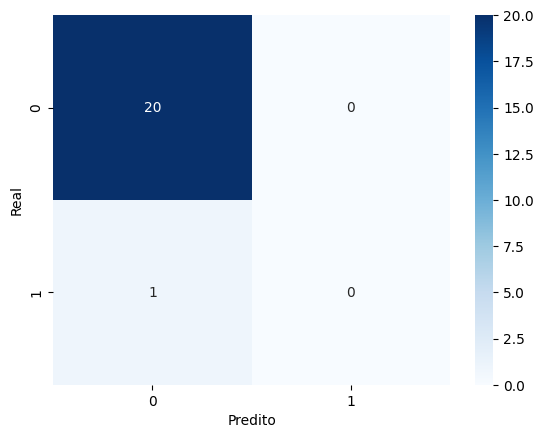

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       0.00      0.00      0.00         1

    accuracy                           0.95        21
   macro avg       0.48      0.50      0.49        21
weighted avg       0.91      0.95      0.93        21



c:\Users\kened\OneDrive\Desktop\Estudos\Lean\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kened\OneDrive\Desktop\Estudos\Lean\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kened\OneDrive\Desktop\Estudos\Lean\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [61]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

print(classification_report(y_test, y_pred))

1° modelo - Regressão logística

Embora a acurácia do modelo esteja em 95%, notamos que, para esse caso em específico, por si só não pode ser fator determinante de um bom modelo, haja vista que precisão e recall para a classe 1, que é aquela que nos indica que o modelo acerta bem virus com alto risco,está em 0.
Esse situação é "normal" dado a quantidade de dados que temos para treinar o modelo e o desbalanceamento das classes já anteriormente relatado.

In [62]:
modelo_lr2 = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
modelo_lr2.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [63]:
y_pred = modelo_lr2.predict(X_test)

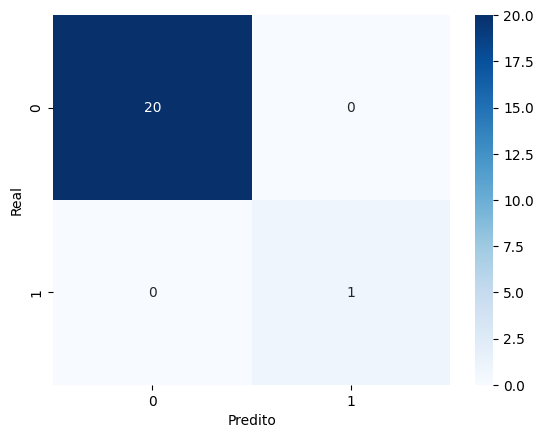

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         1

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [64]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

print(classification_report(y_test, y_pred))

2° modelo - Regressão logística

Adicionei o parâmetro class_weight='balanced' pra compensar o desbalanceamento das classes.
Resultados:
- Todas as métricas em 1.00 (acurácia, recall, precision, F1)
- O modelo acertou todos os 21 vírus do teste, incluindo o único high risk

Apesar do resultado ser visualmente "perfeito", ele não é confiável. O teste tem apenas 1 exemplo da classe positiva, então acertar esse 1 dá recall = 100% por construção,mas não permite a avaliação estatística real do modelo.


In [65]:
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

In [66]:
y_pred = y.copy()

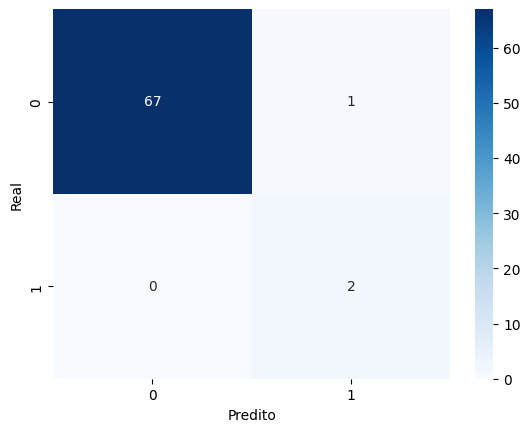

              precision    recall  f1-score   support

           0       1.00      0.99      0.99        68
           1       0.67      1.00      0.80         2

    accuracy                           0.99        70
   macro avg       0.83      0.99      0.90        70
weighted avg       0.99      0.99      0.99        70



In [67]:
for train_idx, test_idx in skf.split(X_encoded, y):
    X_tr, y_tr = RandomOverSampler(sampling_strategy={1: 10}, random_state=42).fit_resample(X_encoded.iloc[train_idx], y.iloc[train_idx])
    modelo = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42).fit(X_tr, y_tr)
    y_pred.iloc[test_idx] = modelo.predict(X_encoded.iloc[test_idx])

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito'); plt.ylabel('Real'); plt.show()
print(classification_report(y, y_pred))

Modelo 3: Regressão Logística com class_weight + RandomOverSampler

Combinei class_weight='balanced' com RandomOverSampler (sampling_strategy={1: 10}) pra aumentar a representatividade da classe minoritária no treino, mantendo validação cruzada estratificada.

Inicialmente tentei usar SMOTE, mas ele exige pelo menos 2 exemplos da classe minoritária no treino pra interpolar entre eles. Como a validação cruzada estratificada deixa apenas 1 positivo por fold, o SMOTE não roda. Optei pelo RandomOverSampler, que duplica exemplos existentes sem interpolar.

Resultados (agregando os 2 folds):
- Recall classe 1: 1.00 (todos os 2 high risk identificados)
- Precision classe 1: 0.67 (1 falso positivo entre os 3 flagrados como high)
- F1 classe 1: 0.80
- Acurácia: 0.99

Esse é o melhor resultado até agora. Recall máximo significa zero falsos negativos, que é o cenário mais crítico pro problema.

In [68]:
dataset = pd.read_csv('C:/Users/kened/OneDrive/Desktop/Estudos/Lean/data/processed/virus_processed.csv')
falsos_positivos = y[(y == 0) & (y_pred == 1)]
dataset.loc[falsos_positivos.index]

,virus_id,family,genus,genome_type,strand,enveloped,transmission,mortality,r0,host,target
30,31,Unknown,Unknown,Unknown,Unknown,Unknown,contact,99.9,2.36,Unknown,0


## Análise do falso positivo

O único falso positivo do modelo é o vírus_id 31, classificado pelo modelo como high risk mas rotulado como low na base original.

Esse mesmo registro já tinha sido visto na EDA como suspeito de erro de rotulagem: ele apresenta mortality de 99.9% (extremamente alta) sem nenhuma caracterização biológica (todas as features categóricas são "Unknown"). A combinação contradiz o "padrão" observado no dataset, onde mortality alta tende a estar associada a alto risco.

O modelo classificar esse registro como high provavelmente reflete um problema na rotulagem do dataset. Erros de rotulagem são comuns em cenários reais, e quando o modelo aprende com dados assim ele acaba "errando" justamente nos pontos onde o rótulo é que está errado. Então, em um cenário real, esse caso mereceria revisão por um especialista.

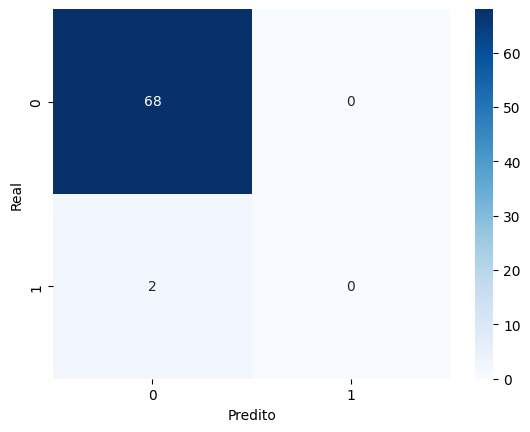

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        68
           1       0.00      0.00      0.00         2

    accuracy                           0.97        70
   macro avg       0.49      0.50      0.49        70
weighted avg       0.94      0.97      0.96        70



c:\Users\kened\OneDrive\Desktop\Estudos\Lean\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kened\OneDrive\Desktop\Estudos\Lean\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kened\OneDrive\Desktop\Estudos\Lean\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [69]:
for train_idx, test_idx in skf.split(X_encoded, y):
    X_tr, y_tr = RandomOverSampler(sampling_strategy={1: 10}, random_state=42).fit_resample(X_encoded.iloc[train_idx], y.iloc[train_idx])
    modelo = RandomForestClassifier(class_weight='balanced', random_state=42).fit(X_tr, y_tr)
    y_pred.iloc[test_idx] = modelo.predict(X_encoded.iloc[test_idx])

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito'); plt.ylabel('Real'); plt.show()
print(classification_report(y, y_pred))

Modelo 4: Random Forest com class_weight + RandomOverSampler

Repeti a mesma estratégia do modelo anterior, trocando regressão logística por Random Forest pra ver se um modelo mais complexo melhoraria o resultado.

Resultados:
- Recall classe 1: 0.00
- Precision classe 1: 0.00
- F1 classe 1: 0.00
- Acurácia: 0.97

O modelo previu 0 pra todos os vírus. Random Forest tende a sofrer mais com classes pequenas e mostrou que algoritmo mais complexo não significa modelo melhor, principalmente em datasets pequenos e desbalanceados como esse.

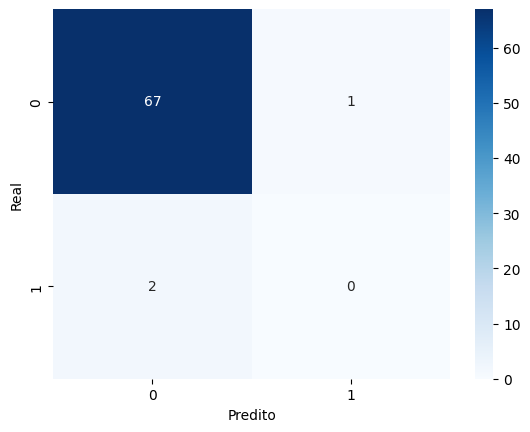

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        68
           1       0.00      0.00      0.00         2

    accuracy                           0.96        70
   macro avg       0.49      0.49      0.49        70
weighted avg       0.94      0.96      0.95        70



In [70]:
for train_idx, test_idx in skf.split(X_encoded, y):
    X_tr, y_tr = RandomOverSampler(sampling_strategy={1: 10}, random_state=42).fit_resample(X_encoded.iloc[train_idx], y.iloc[train_idx])
    modelo = XGBClassifier(scale_pos_weight=34, random_state=42, eval_metric='logloss').fit(X_tr, y_tr)
    y_pred.iloc[test_idx] = modelo.predict(X_encoded.iloc[test_idx])

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito'); plt.ylabel('Real'); plt.show()
print(classification_report(y, y_pred))

Modelo 5: XGBoost com scale_pos_weight + RandomOverSampler

Testei o XGBoost com scale_pos_weight=34 (equivalente ao class_weight='balanced'), mantendo o mesmo pipeline.

Resultados:
- Recall classe 1: 0.00
- Precision classe 1: 0.00
- F1 classe 1: 0.00
- Acurácia: 0.96

Mesmo resultado fraco do Random Forest, confirmando que modelos baseados em árvore não conseguiram capturar o sinal da classe minoritária com tão poucos exemplos, mesmo com peso ajustado e oversampling.